# Ensemble Learning: AdaBoost — Step-by-Step from Scratch

---

## Introduction

**AdaBoost** (Adaptive Boosting) is a sequential ensemble method that combines many weak learners — classifiers that perform only slightly better than random guessing — into a single strong classifier.

Unlike Bagging and Random Forest, which train trees in **parallel** on random data subsets, AdaBoost trains each new learner **sequentially**, with each iteration focusing more attention on the samples that the previous learner got wrong. This is achieved by maintaining a **weight** for every training sample and updating those weights after each round.

### The AdaBoost Algorithm (per round)

| Step | Action |
|---|---|
| 1 | Initialize all sample weights equally: $w_i = \frac{1}{N}$ |
| 2 | Train a weak learner (depth-1 Decision Tree) on the weighted data |
| 3 | Compute weighted error: $\varepsilon = \sum w_i \cdot \mathbf{1}[y_i \neq \hat{y}_i]$ |
| 4 | Compute model weight: $\alpha = \frac{1}{2} \ln\left(\frac{1 - \varepsilon}{\varepsilon}\right)$ |
| 5 | Update sample weights: increase for misclassified, decrease for correct |
| 6 | Normalize weights so they sum to 1 |
| 7 | Build next dataset by sampling according to the updated weights |
| 8 | Repeat for the next round |

**Final prediction** is the weighted majority vote:
$$F(x) = \text{sign}\left(\sum_{t=1}^{T} \alpha_t \cdot h_t(x)\right)$$

This notebook implements all of these steps manually on a small 10-sample dataset across **three boosting rounds**, making the mechanics fully transparent before using scikit-learn's implementation.

---

## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from mlxtend.plotting import plot_decision_regions

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

---

## 2. Dataset

We construct a small 10-sample dataset with two features (`X1`, `X2`) and a binary label (0 or 1). The small size makes it possible to trace every weight update by hand alongside the code.

In [2]:
df = pd.DataFrame({
    'X1':    [1, 2, 3, 4, 5, 6, 6, 7, 9, 9],
    'X2':    [5, 3, 6, 8, 1, 9, 5, 8, 9, 2],
    'label': [1, 1, 0, 1, 0, 1, 0, 1, 0, 0]
})

print('Dataset shape:', df.shape)
print('Class balance:', df['label'].value_counts().to_dict())
df

Dataset shape: (10, 3)
Class balance: {1: 5, 0: 5}


,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


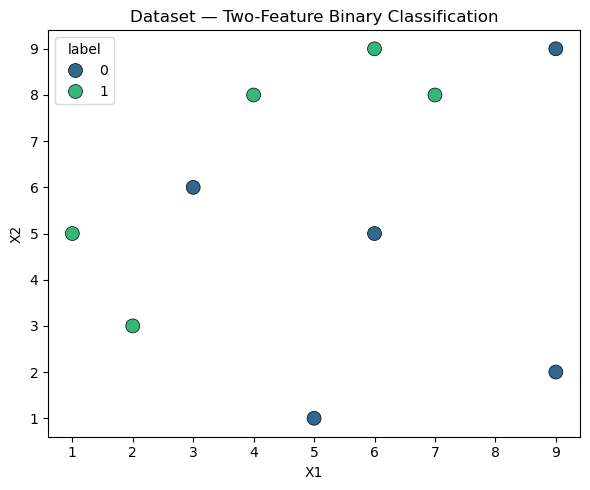

In [3]:
plt.figure(figsize=(6, 5))
sns.scatterplot(x=df['X1'], y=df['X2'], hue=df['label'],
                palette='viridis', s=100, edgecolor='k', linewidth=0.5)
plt.title('Dataset — Two-Feature Binary Classification')
plt.xlabel('X1')
plt.ylabel('X2')
plt.tight_layout()
plt.show()

---

## 3. Helper Functions

Two utility functions implement the core AdaBoost update rules:
- `calculate_model_weight` — computes $\alpha$ from the weighted error
- `update_row_weights` — increases weights for misclassified samples, decreases for correct ones
- `create_new_dataset` — performs weighted bootstrap sampling using cumulative weight buckets

In [8]:
def calculate_model_weight(error):
    """Compute alpha: the model's voting weight. Higher alpha = lower error."""
    return 0.5 * np.log((1 - error) / error)


def update_row_weights(row, alpha):
    """
    Update sample weight after a boosting round.
    - Misclassified samples: weight * exp(+alpha)  -> increase
    - Correct samples:       weight * exp(-alpha)  -> decrease
    """
    if row['label'] == row['y_pred']:
        return row['weights'] * np.exp(-alpha)
    else:
        return row['weights'] * np.exp(alpha)


def create_new_dataset(df):
    """
    Weighted bootstrap sampling using cumulative weight intervals.
    Samples with higher normalized weight occupy a wider interval
    and are more likely to be drawn.
    """
    indices = []
    for _ in range(df.shape[0]):
        a = np.random.random()
        for index, row in df.iterrows():
            if row['cumsum_lower'] < a <= row['cumsum_upper']:
                indices.append(index)
                break
    return indices

---

## 4. Round 1 — First Weak Learner

### Step 1: Initialize Uniform Weights

Every sample starts with equal weight $w_i = \frac{1}{N} = 0.1$. No sample is considered more important than any other at the start.

In [9]:
df['weights'] = 1 / df.shape[0]
print(f'Initial weight per sample: {df["weights"].iloc[0]:.2f}   Sum: {df["weights"].sum():.1f}')
df[['X1', 'X2', 'label', 'weights']]

Initial weight per sample: 0.10   Sum: 1.0


,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


### Step 2: Train Weak Learner 1

A depth-1 Decision Tree (a **decision stump**) is the canonical weak learner for AdaBoost. It makes a single axis-aligned split — just one threshold on one feature — producing a very simple boundary that is barely better than random guessing.

In [10]:
X = df[['X1', 'X2']].values
y = df['label'].values

dt1 = DecisionTreeClassifier(max_depth=1, random_state=42)
dt1.fit(X, y)

df['y_pred'] = dt1.predict(X)

n_wrong = (df['label'] != df['y_pred']).sum()
print(f'Stump 1 — Misclassified: {n_wrong} / {len(df)}')
df[['X1', 'X2', 'label', 'weights', 'y_pred']]

Stump 1 — Misclassified: 3 / 10


,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,0
6,6,5,0,0.1,0
7,7,8,1,0.1,0
8,9,9,0,0.1,0
9,9,2,0,0.1,0


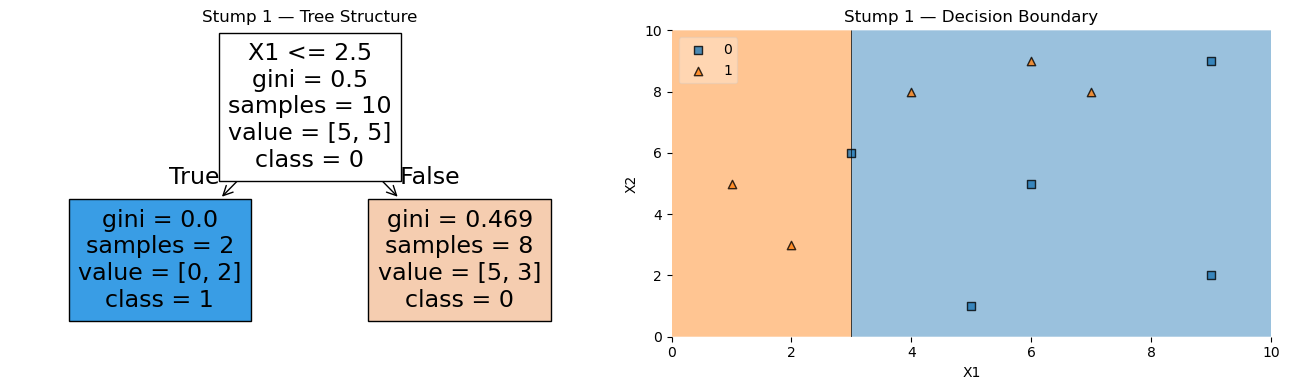

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plot_tree(dt1, feature_names=['X1', 'X2'], class_names=['0', '1'],
          filled=True, ax=axes[0])
axes[0].set_title('Stump 1 — Tree Structure')

plt.sca(axes[1])
plot_decision_regions(X, y, clf=dt1, legend=2)
axes[1].set_title('Stump 1 — Decision Boundary')
axes[1].set_xlabel('X1')
axes[1].set_ylabel('X2')

plt.tight_layout()
plt.show()

### Steps 3–4: Compute Weighted Error and Model Weight (alpha)

The weighted error $\varepsilon_1$ is the sum of weights of misclassified samples. Here all weights are equal (0.1), so $\varepsilon_1 = 0.3$ (3 misclassified samples).

The model weight $\alpha_1 = \frac{1}{2} \ln\left(\frac{1-0.3}{0.3}\right) \approx 0.42$. A lower error produces a higher alpha — more say in the final vote.

In [12]:
error1 = (df['weights'] * (df['label'] != df['y_pred'])).sum()
alpha1 = calculate_model_weight(error1)

print(f'Weighted error (eps1) : {error1:.4f}')
print(f'Model weight  (alpha1): {alpha1:.4f}')

Weighted error (eps1) : 0.3000
Model weight  (alpha1): 0.4236


### Steps 5–6: Update and Normalize Sample Weights

Misclassified samples have their weight multiplied by $e^{+\alpha}$ (increased). Correctly classified samples are multiplied by $e^{-\alpha}$ (decreased). Weights are then normalized to sum to 1, forming a valid probability distribution for the next sampling step.

In [13]:
df['updated_weights'] = df.apply(update_row_weights, axis=1, alpha=alpha1)
df['normalized_weights'] = df['updated_weights'] / df['updated_weights'].sum()

print(f'Sum of updated weights     : {df["updated_weights"].sum():.4f}')
print(f'Sum of normalized weights  : {df["normalized_weights"].sum():.4f}')
df[['X1', 'X2', 'label', 'weights', 'y_pred', 'updated_weights', 'normalized_weights']]

Sum of updated weights     : 0.9165
Sum of normalized weights  : 1.0000


,X1,X2,label,weights,y_pred,updated_weights,normalized_weights
0,1,5,1,0.1,1,0.065465,0.071429
1,2,3,1,0.1,1,0.065465,0.071429
2,3,6,0,0.1,0,0.065465,0.071429
3,4,8,1,0.1,0,0.152753,0.166667
4,5,1,0,0.1,0,0.065465,0.071429
5,6,9,1,0.1,0,0.152753,0.166667
6,6,5,0,0.1,0,0.065465,0.071429
7,7,8,1,0.1,0,0.152753,0.166667
8,9,9,0,0.1,0,0.065465,0.071429
9,9,2,0,0.1,0,0.065465,0.071429


### Step 7: Build Next Dataset via Weighted Sampling

Cumulative weight intervals are computed. A random number between 0 and 1 is drawn for each new sample — the sample whose interval contains that number is selected. Samples with higher normalized weight occupy wider intervals and are more likely to be picked, giving Round 2 a training set that focuses on the previously misclassified points.

In [14]:
df['cumsum_upper'] = np.cumsum(df['normalized_weights'])
df['cumsum_lower'] = df['cumsum_upper'] - df['normalized_weights']

df[['X1', 'X2', 'label', 'weights', 'y_pred',
    'normalized_weights', 'cumsum_lower', 'cumsum_upper']]

,X1,X2,label,weights,y_pred,normalized_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.071429,0.000000,0.071429
1,2,3,1,0.1,1,0.071429,0.071429,0.142857
2,3,6,0,0.1,0,0.071429,0.142857,0.214286
3,4,8,1,0.1,0,0.166667,0.214286,0.380952
4,5,1,0,0.1,0,0.071429,0.380952,0.452381
5,6,9,1,0.1,0,0.166667,0.452381,0.619048
6,6,5,0,0.1,0,0.071429,0.619048,0.690476
7,7,8,1,0.1,0,0.166667,0.690476,0.857143
8,9,9,0,0.1,0,0.071429,0.857143,0.928571
9,9,2,0,0.1,0,0.071429,0.928571,1.000000


In [25]:
index_values = create_new_dataset(df)
second_df = df.iloc[index_values, [0, 1, 2, 3]].copy()

print('Sampled indices for Round 2:', index_values)
second_df

Sampled indices for Round 2: [3, 9, 7, 5, 2, 2, 0, 8, 5, 7]


,X1,X2,label,weights
3,4,8,1,0.1
9,9,2,0,0.1
7,7,8,1,0.1
5,6,9,1,0.1
2,3,6,0,0.1
2,3,6,0,0.1
0,1,5,1,0.1
8,9,9,0,0.1
5,6,9,1,0.1
7,7,8,1,0.1


---

## 5. Round 2 — Second Weak Learner

The second stump is trained on the resampled dataset, which now over-represents the samples that Round 1 misclassified. This forces the new learner to focus its single split on the harder examples.

In [26]:
X2_arr = second_df[['X1', 'X2']].values
y2_arr = second_df['label'].values

dt2 = DecisionTreeClassifier(max_depth=1, random_state=42)
dt2.fit(X2_arr, y2_arr)

second_df['y_pred'] = dt2.predict(X2_arr)

error2 = (second_df['weights'] * (second_df['label'] != second_df['y_pred'])).sum()
alpha2 = calculate_model_weight(error2)

print(f'Weighted error (eps2) : {error2:.4f}')
print(f'Model weight  (alpha2): {alpha2:.4f}')

Weighted error (eps2) : 0.2000
Model weight  (alpha2): 0.6931


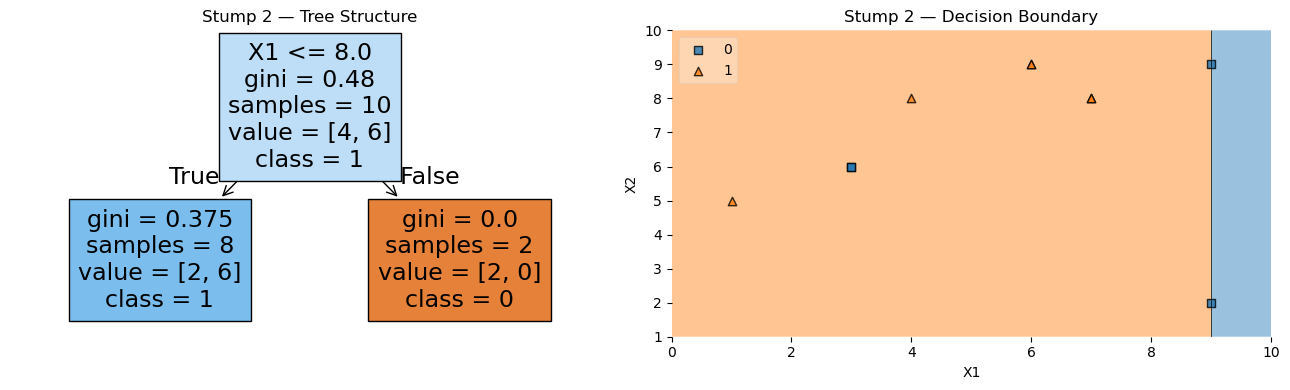

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plot_tree(dt2, feature_names=['X1', 'X2'], class_names=['0', '1'],
          filled=True, ax=axes[0])
axes[0].set_title('Stump 2 — Tree Structure')

plt.sca(axes[1])
plot_decision_regions(X2_arr, y2_arr, clf=dt2, legend=2)
axes[1].set_title('Stump 2 — Decision Boundary')
axes[1].set_xlabel('X1')
axes[1].set_ylabel('X2')

plt.tight_layout()
plt.show()

In [28]:
second_df['updated_weights'] = second_df.apply(update_row_weights, axis=1, alpha=alpha2)
second_df['normalized_weights'] = second_df['updated_weights'] / second_df['updated_weights'].sum()
second_df['cumsum_upper'] = np.cumsum(second_df['normalized_weights'])
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['normalized_weights']

second_df[['X1', 'X2', 'label', 'weights', 'y_pred',
            'normalized_weights', 'cumsum_lower', 'cumsum_upper']]

,X1,X2,label,weights,y_pred,normalized_weights,cumsum_lower,cumsum_upper
3,4,8,1,0.1,1,0.0625,0.0000,0.0625
9,9,2,0,0.1,0,0.0625,0.0625,0.1250
7,7,8,1,0.1,1,0.0625,0.1250,0.1875
5,6,9,1,0.1,1,0.0625,0.1875,0.2500
2,3,6,0,0.1,1,0.2500,0.2500,0.5000
2,3,6,0,0.1,1,0.2500,0.5000,0.7500
0,1,5,1,0.1,1,0.0625,0.7500,0.8125
8,9,9,0,0.1,0,0.0625,0.8125,0.8750
5,6,9,1,0.1,1,0.0625,0.8750,0.9375
7,7,8,1,0.1,1,0.0625,0.9375,1.0000


In [29]:
index_values = create_new_dataset(second_df)
third_df = second_df.iloc[index_values, [0, 1, 2, 3]].copy()

print('Sampled indices for Round 3:', index_values)
third_df

Sampled indices for Round 3: [3, 7, 8, 5, 7, 7, 2, 2, 2, 2]


,X1,X2,label,weights
5,6,9,1,0.1
8,9,9,0,0.1
5,6,9,1,0.1
2,3,6,0,0.1
8,9,9,0,0.1
8,9,9,0,0.1
7,7,8,1,0.1
7,7,8,1,0.1
7,7,8,1,0.1
7,7,8,1,0.1


---

## 6. Round 3 — Third Weak Learner

In [30]:
X3_arr = third_df[['X1', 'X2']].values
y3_arr = third_df['label'].values

dt3 = DecisionTreeClassifier(max_depth=1, random_state=42)
dt3.fit(X3_arr, y3_arr)

third_df['y_pred'] = dt3.predict(X3_arr)

error3 = (third_df['weights'] * (third_df['label'] != third_df['y_pred'])).sum()
alpha3 = calculate_model_weight(error3)

print(f'Weighted error (eps3) : {error3:.4f}')
print(f'Model weight  (alpha3): {alpha3:.4f}')

Weighted error (eps3) : 0.1000
Model weight  (alpha3): 1.0986


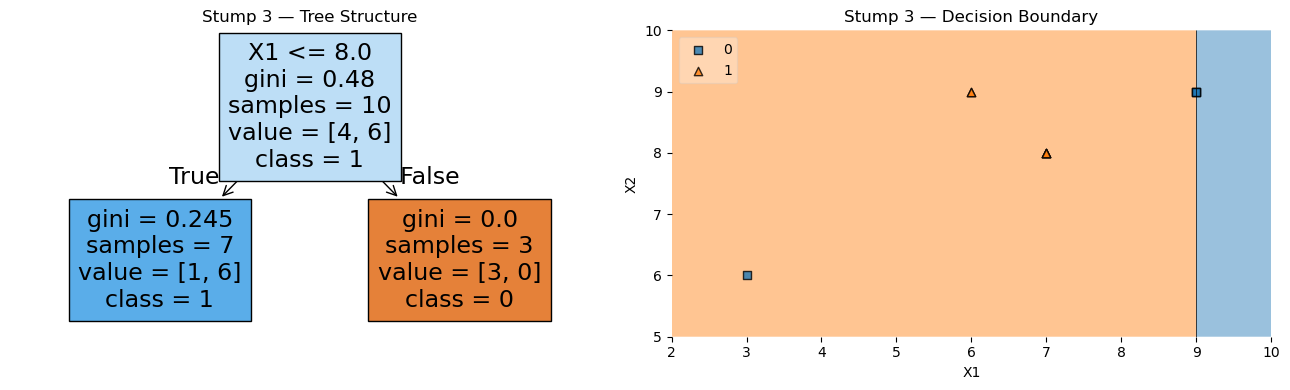

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plot_tree(dt3, feature_names=['X1', 'X2'], class_names=['0', '1'],
          filled=True, ax=axes[0])
axes[0].set_title('Stump 3 — Tree Structure')

plt.sca(axes[1])
plot_decision_regions(X3_arr, y3_arr, clf=dt3, legend=2)
axes[1].set_title('Stump 3 — Decision Boundary')
axes[1].set_xlabel('X1')
axes[1].set_ylabel('X2')

plt.tight_layout()
plt.show()

---

## 7. Model Weights Summary

The alpha values determine how much each stump contributes to the final prediction. A lower error produces a higher alpha, giving that stump more influence in the weighted majority vote.

In [32]:
print('Model Weight Summary')
print('-' * 40)
print(f'Stump 1 — alpha1 : {alpha1:.4f}')
print(f'Stump 2 — alpha2 : {alpha2:.4f}')
print(f'Stump 3 — alpha3 : {alpha3:.4f}')

Model Weight Summary
----------------------------------------
Stump 1 — alpha1 : 0.4236
Stump 2 — alpha2 : 0.6931
Stump 3 — alpha3 : 1.0986


---

## 8. Weighted Majority Vote Prediction

The final AdaBoost prediction is:

$$F(x) = \text{sign}\left(\alpha_1 \cdot h_1(x) + \alpha_2 \cdot h_2(x) + \alpha_3 \cdot h_3(x)\right)$$

Each stump's prediction is converted to $\{+1, -1\}$ (class 1 → +1, class 0 → -1), weighted by its alpha, and summed. The sign of the total determines the final class.

We test two query points from the original dataset to verify the ensemble agrees with the ground truth.

In [33]:
def adaboost_predict(stumps, alphas, query):
    """
    Weighted majority vote across all stumps.
    Converts predictions to +1/-1 before weighting.
    """
    vote = 0
    for clf, alpha in zip(stumps, alphas):
        pred = clf.predict(query)[0]
        signed_pred = 1 if pred == 1 else -1
        vote += alpha * signed_pred
        print(f'  Stump prediction: {pred}  (signed: {signed_pred:+.0f})  alpha: {alpha:.4f}')
    print(f'  Weighted sum : {vote:.4f}')
    print(f'  Final class  : {int(np.sign(vote))}   (sign of sum)')
    return int(np.sign(vote))

stumps = [dt1, dt2, dt3]
alphas = [alpha1, alpha2, alpha3]

In [34]:
# Query 1: [X1=1, X2=5] — true label = 1
query1 = np.array([1, 5]).reshape(1, 2)
print('Query: [X1=1, X2=5]  |  True label: 1')
print('-' * 45)
result1 = adaboost_predict(stumps, alphas, query1)

Query: [X1=1, X2=5]  |  True label: 1
---------------------------------------------
  Stump prediction: 1  (signed: +1)  alpha: 0.4236
  Stump prediction: 1  (signed: +1)  alpha: 0.6931
  Stump prediction: 1  (signed: +1)  alpha: 1.0986
  Weighted sum : 2.2154
  Final class  : 1   (sign of sum)


In [35]:
# Query 2: [X1=9, X2=9] — true label = 0
query2 = np.array([9, 9]).reshape(1, 2)
print('Query: [X1=9, X2=9]  |  True label: 0')
print('-' * 45)
result2 = adaboost_predict(stumps, alphas, query2)

Query: [X1=9, X2=9]  |  True label: 0
---------------------------------------------
  Stump prediction: 0  (signed: -1)  alpha: 0.4236
  Stump prediction: 0  (signed: -1)  alpha: 0.6931
  Stump prediction: 0  (signed: -1)  alpha: 1.0986
  Weighted sum : -2.2154
  Final class  : -1   (sign of sum)


---

## Conclusion

This notebook implemented the AdaBoost algorithm from scratch across three boosting rounds on a 10-sample dataset, making every weight update, model weight calculation, and sampling step fully visible.

**Key findings:**

- **Round 1** starts with uniform weights. The first stump makes its best single split across all samples, misclassifying 3. Those samples receive higher weights for Round 2.
- **Round 2** trains on a resampled dataset that over-represents the Round 1 mistakes. The new stump produces a different split that compensates for the earlier errors — its alpha reflects its lower error rate, giving it more voting power.
- **Round 3** repeats the process on the Round 2-weighted distribution. Each round progressively shifts focus to the hardest samples.
- The **weighted majority vote** combines all three stumps: each stump's $\pm1$ prediction is scaled by its alpha and summed. The sign of the total determines the final class — stumps with lower error contribute more to the decision.
- Both test queries are correctly classified by the ensemble, demonstrating that combining weak learners with complementary strengths produces a stronger overall classifier.

**Takeaways:**

- AdaBoost's power comes from the **adaptive weight update**: each round is not independent — it directly builds on the failures of all previous rounds.
- A stump with error = 0.5 (random guessing) gets $\alpha = 0$ — it contributes nothing. A stump with error > 0.5 gets negative alpha — it would actually hurt the ensemble.
- In practice, `sklearn.ensemble.AdaBoostClassifier` handles all of this automatically and efficiently. Understanding the manual steps here makes its `learning_rate`, `n_estimators`, and `algorithm` parameters intuitive to tune.
- AdaBoost is sensitive to noisy labels and outliers — because they are repeatedly misclassified, they accumulate very high weights and can dominate later rounds.